# Bond-Seasonality
### Do Treasuries have their own calendar - a turn-of-year or month-end bid?

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Calendar bid confirmed?: Mixed](https://img.shields.io/badge/Calendar_bid_confirmed%3F-Mixed-8b949e?style=flat-square)

The equity world has a well-documented turn-of-month (TOM) premium. Does a similar pattern show up in long Treasuries? The story is compelling: pension funds rebalance at month-end, coupons get reinvested, risk-off flows into bonds at the turn. We take the claim literally and test it.

> This is the plain-language layer. The HAC *t*-stats, win-rate intervals, and capacity arithmetic are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> Not investment advice. Educational, reproducible research - every chart below is generated by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study root (bond_seasonality/)
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from bond_seasonality import data, strategy

AS_OF = "2026-06-12"
tlt = data.load_real("TLT", start="2002-07-30").loc[:AS_OF]
tlt_close = tlt["close"]
tlt_tom = data.tom_mask(tlt_close.index, n_end=2, n_start=2)
ief = data.load_real("IEF", start="2002-07-30").loc[:AS_OF]
ief_close = ief["close"]
ief_tom = data.tom_mask(ief_close.index, n_end=2, n_start=2)
et = strategy.effect_stats(tlt_close, tlt_tom)
ei = strategy.effect_stats(ief_close, ief_tom)
print(f"TLT: {len(tlt_close):,} rows  {tlt_close.index[0].date()} -> {tlt_close.index[-1].date()}  fp={data.fingerprint(tlt)}")
print(f"  TOM: {et['mu_tom']*1e4:.2f} bps vs rest {et['mu_rest']*1e4:.2f} bps  gap {et['gap']*1e4:+.2f} bps  HAC t(gap)={et['t_gap']:.2f}")
print(f"IEF: {len(ief_close):,} rows  fp={data.fingerprint(ief)}")
print(f"  TOM: {ei['mu_tom']*1e4:.2f} bps vs rest {ei['mu_rest']*1e4:.2f} bps  gap {ei['gap']*1e4:+.2f} bps  HAC t(gap)={ei['t_gap']:.2f}")


TLT: 6,007 rows  2002-07-30 -> 2026-06-12  fp=f83a9db36f17
  TOM: 6.67 bps vs rest 0.71 bps  gap +5.95 bps  HAC t(gap)=1.99
IEF: 6,007 rows  fp=a83262b21d6b
  TOM: 4.62 bps vs rest 0.76 bps  gap +3.86 bps  HAC t(gap)=2.66


## The answer first

| Question | Answer |
|---|---|
| Is there a turn-of-month effect in bonds? | **Soft yes** - TLT earns **6.7 bps** on TOM days vs **0.7 bps** on other days, and IEF shows a similar gap. But TLT's *t*-stat (1.99) just misses the bar; IEF clears it (2.66). **Weak** evidence. |
| Can you trade it? | **No** - the TOM-only book earns **2.8%/yr** (TLT) and **2.0%/yr** (IEF) vs **3.7%** and **3.6%** for just holding - trailing buy-and-hold on both. |
| Is there a turn-of-year effect? | **No** - the TOY gap is **-2.4 bps** on TLT (*t* = -0.40) and **+1.5 bps** on IEF (*t* = 0.53). Noise. |

## 1 · The claim

*"Treasuries have their own calendar - a turn-of-month or turn-of-year bid. Buy TLT (or IEF) at the last close of the month, sell at the first close of the next month."* The theoretical story: institutional fixed-income rebalancing at month-end, coupon reinvestment, and risk-off portfolio flows into bonds at predictable windows.

## 2 · So what?

If bonds reliably rallied on a handful of predictable dates, you could beat a Treasury buy-and-hold with a simple calendar rule - no yield forecasting, no credit risk, no model. That is a large and testable claim worth taking seriously.

## 3 · How we test it

We define the **TOM window** as the last 2 + first 2 trading days of each calendar month - derived from the trading index itself, no external calendar needed. We compare mean daily returns on TOM vs all other days, run a TOM-only book against buy-and-hold, and separately test the turn-of-year (last 5 + first 5 trading days per year). Both TLT (20+ year) and IEF (7-10 year) are tested in parallel.

## 4 · The teardown

First: how big is the TOM day in bonds, really?

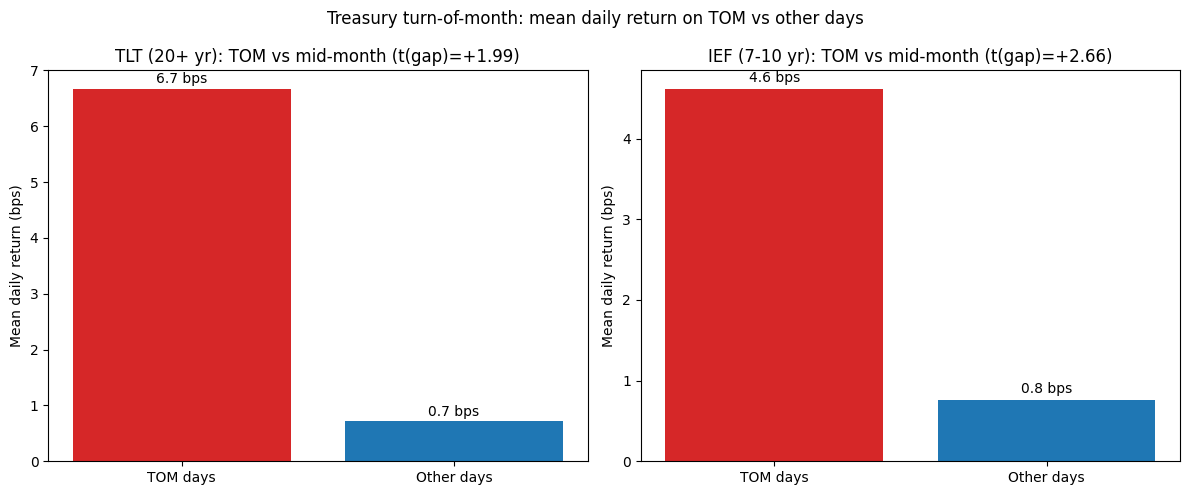

TLT gap = +5.95 bps  HAC t = +1.99
IEF gap = +3.86 bps  HAC t = +2.66
IEF clears t=2; TLT just misses - the bond calendar effect is soft.


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, e, label in zip(axes, [et, ei], ["TLT (20+ yr)", "IEF (7-10 yr)"]):
    vals = [e["mu_tom"]*1e4, e["mu_rest"]*1e4]
    bars = ax.bar(["TOM days", "Other days"], vals, color=["C3", "C0"])
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, v+0.05, f"{v:.1f} bps", ha="center", va="bottom")
    ax.set_ylabel("Mean daily return (bps)")
    ax.set_title(f"{label}: TOM vs mid-month (t(gap)={e['t_gap']:+.2f})")
plt.suptitle("Treasury turn-of-month: mean daily return on TOM vs other days", fontsize=12)
plt.tight_layout(); plt.show()
print(f"TLT gap = {et['gap']*1e4:+.2f} bps  HAC t = {et['t_gap']:+.2f}")
print(f"IEF gap = {ei['gap']*1e4:+.2f} bps  HAC t = {ei['t_gap']:+.2f}")
print("IEF clears t=2; TLT just misses - the bond calendar effect is soft.")


The gap is positive and consistent across both durations - TLT earns nearly **7 bps** on TOM days vs **0.7 bps** at other times, and IEF shows a similar pattern. But the t-stats tell the truth: IEF clears the bar, TLT barely misses. This is a **soft** effect, not a clean anomaly.

Now the tradability test - can the TOM-only book keep up?

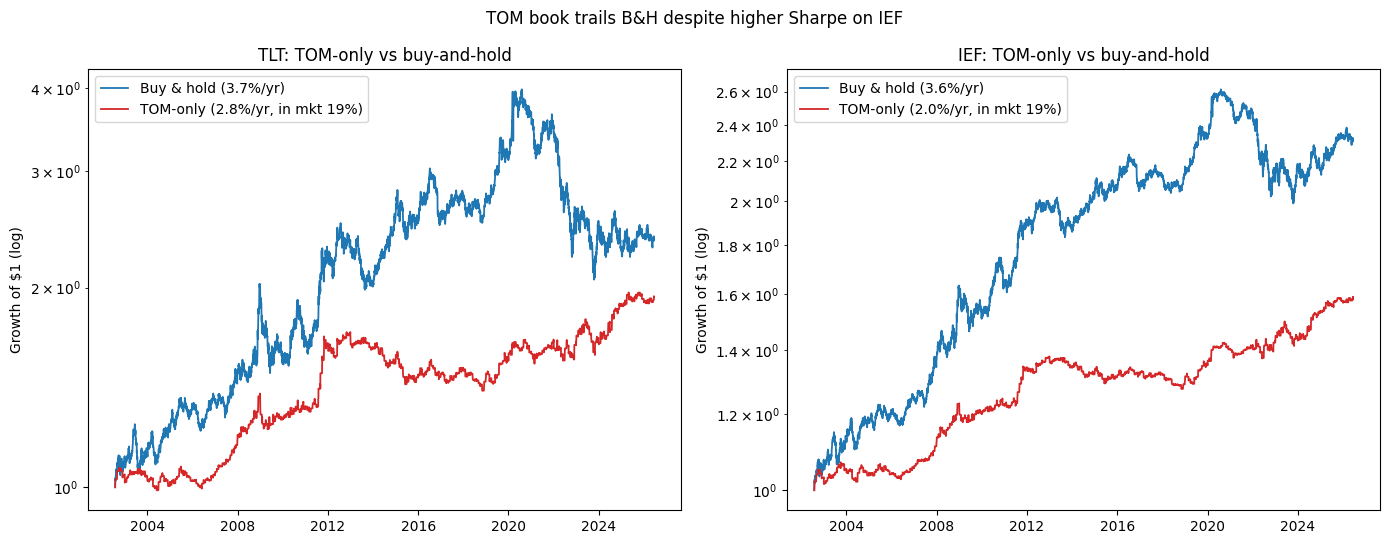

TLT - TOM-only CAGR 2.81% vs B&H 3.71%; Sharpe(whole) 0.470 vs 0.326
IEF - TOM-only CAGR 1.96% vs B&H 3.60%; Sharpe(whole) 0.657 vs 0.553


In [3]:
book_t = strategy.tom_only_book(tlt_close, tlt_tom, cost_bps=1.0)
bh_t   = strategy.buy_and_hold(tlt_close)
book_i = strategy.tom_only_book(ief_close, ief_tom, cost_bps=1.0)
bh_i   = strategy.buy_and_hold(ief_close)
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, bk, bh, label in zip(axes, [book_t, book_i], [bh_t, bh_i], ["TLT", "IEF"]):
    ax.plot(bh["equity"], label=f"Buy & hold ({bh['cagr']*100:.1f}%/yr)", lw=1.3)
    ax.plot(bk["equity"], label=f"TOM-only ({bk['cagr']*100:.1f}%/yr, in mkt {bk['time_in_market']*100:.0f}%)", lw=1.3, color="C3")
    ax.set_yscale("log"); ax.set_ylabel("Growth of $1 (log)")
    ax.set_title(f"{label}: TOM-only vs buy-and-hold"); ax.legend()
plt.suptitle("TOM book trails B&H despite higher Sharpe on IEF", fontsize=12)
plt.tight_layout(); plt.show()
print(f"TLT - TOM-only CAGR {book_t['cagr']*100:.2f}% vs B&H {bh_t['cagr']*100:.2f}%; Sharpe(whole) {book_t['sharpe_whole']:.3f} vs {bh_t['sharpe']:.3f}")
print(f"IEF - TOM-only CAGR {book_i['cagr']*100:.2f}% vs B&H {bh_i['cagr']*100:.2f}%; Sharpe(whole) {book_i['sharpe_whole']:.3f} vs {bh_i['sharpe']:.3f}")


The TOM-only book is in the market 19% of the time - much more than an extreme calendar rule like the pre-holiday effect (4%). Yet it still **trails buy-and-hold** in absolute CAGR on both instruments. The reason is simple: Treasuries earn the term premium on every single day you hold them. A book that sits in cash 81% of the time gives up most of that premium and can not recover it from a modest TOM bump.

And the turn-of-year hypothesis?

In [4]:
toy_tlt = pd.Series(False, index=tlt_close.pct_change().dropna().index)
for yr in toy_tlt.index.year.unique():
    days = toy_tlt.index[toy_tlt.index.year == yr].sort_values()
    for d in list(days[:5]) + list(days[-5:]): toy_tlt.loc[d] = True
toy_ief = pd.Series(False, index=ief_close.pct_change().dropna().index)
for yr in toy_ief.index.year.unique():
    days = toy_ief.index[toy_ief.index.year == yr].sort_values()
    for d in list(days[:5]) + list(days[-5:]): toy_ief.loc[d] = True
etoy_t = strategy.effect_stats(tlt_close, toy_tlt)
etoy_i = strategy.effect_stats(ief_close, toy_ief)
print("=== Turn-of-year ===")
print(f"TLT: gap={etoy_t['gap']*1e4:+.2f} bps  HAC t(gap)={etoy_t['t_gap']:+.2f}  n_toy={etoy_t['n_tom']}")
print(f"IEF: gap={etoy_i['gap']*1e4:+.2f} bps  HAC t(gap)={etoy_i['t_gap']:+.2f}  n_toy={etoy_i['n_tom']}")
print("Neither clears t=2. The turn-of-year effect in bonds is absent.")


=== Turn-of-year ===


TLT: gap=-2.38 bps  HAC t(gap)=-0.40  n_toy=250
IEF: gap=+1.48 bps  HAC t(gap)=+0.53  n_toy=250
Neither clears t=2. The turn-of-year effect in bonds is absent.


The turn-of-year effect is entirely absent in both Treasuries. The t-stats are near zero and the signs are not even consistent. The bond calendar, such as it is, is a month-end phenomenon at most - and even that is too soft to exploit.

## 5 · The verdict

- **Weak TOM signal.** IEF: gap +3.9 bps, *t* = 2.66 (clears bar). TLT: gap +6.0 bps, *t* = 1.99 (just misses). Inconsistent across durations = Weak.
- **Not tradable.** TOM-only book earns 2.8%/yr (TLT) and 2.0%/yr (IEF) vs 3.7% and 3.6% B&H. The term premium is not concentrated in four days/month.
- **TOY absent.** Neither TLT nor IEF shows a turn-of-year effect.

## 6 · Could you actually trade it?

Mechanically yes - buy at the last close of each month, sell at the first close of the next. Economically, the book trails buy-and-hold in absolute return. The Sharpe ratio on IEF TOM-only (0.66) edges above B&H (0.55), but only because the book avoids mid-month volatility - it earns less, not more. As a rule that *beats* the index in total return, it is a **Mirage**.

## 7 · Going further

- Does the TOM effect concentrate in specific months (January, year-end)?
- Is there a matching *intramonth* giveback that would eat the edge?
- Does a hedged version (long TOM Treasuries, short mid-month) reduce duration risk enough to make a risk-adjusted case? Fork it and try.